In [3]:
import pandas as pd
#load cleaned dataset
df = pd.read_csv("../data/processed/cleaned_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8523, 13)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Store_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.022911,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.016164,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26


In [4]:
# Target variable
y = df['Item_Outlet_Sales']

#Features
x = df.drop('Item_Outlet_Sales',axis=1)

print("Feature Shape:",x.shape)
print("Target Shape:",y.shape)

Feature Shape: (8523, 12)
Target Shape: (8523,)


In [5]:
x.select_dtypes(include='object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [6]:
x = x.drop (['Item_Identifier','Outlet_Identifier'], axis=1)

print("New Feature Shape:",x.shape)


New Feature Shape: (8523, 10)


In [7]:
x = pd.get_dummies(x, drop_first=True)

print(" Encouded Feature Shape: ",x.shape)
x.head()

 Encouded Feature Shape:  (8523, 28)


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Store_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,14,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,4,True,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,1999,14,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.022911,182.0950,1998,15,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.016164,53.8614,1987,26,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [8]:
!pip install scikit-learn

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (6818, 28)
Testing data shape: (1705, 28)


In [10]:
from sklearn.linear_model import LinearRegression

# create model
lr = LinearRegression()

#train model
lr.fit(x_train, y_train)

print("Model training completed")

Model training completed


In [11]:
y_pred = lr.predict(x_test)

print(y_pred[:10])

[1353.22524774  765.30277011  817.5191853  4227.53298874 3281.11403439
  575.46202873 4778.53611664 2037.56341795 1385.89703414 2774.2141172 ]


In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:",rmse)
print("R2 Score:",r2)
      

RMSE: 1068.4703615162775
R2 Score: 0.5799700197361619


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(x_train,y_train)

print("Random Forest model trained")

Random Forest model trained


In [14]:
rf_pred = rf.predict(x_test)

print(rf_pred[:10])

[ 791.250036  864.401482  840.679028 5067.310588 2195.302392  457.844028
 5725.34736  1303.676348 1007.168976 2774.228808]


In [15]:
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest RMSE:",rmse_rf)
print("Random Forest R2:",r2_rf)

Random Forest RMSE: 1092.296901669416
Random Forest R2: 0.561028086346157


In [16]:
import joblib
joblib.dump(lr,"../models/sales_prediction_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [17]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature":x_train.columns,
    "Importance":lr.coef_
})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
27,Outlet_Type_Supermarket Type3,3798.821753
25,Outlet_Type_Supermarket Type1,1533.207615
26,Outlet_Type_Supermarket Type2,1286.819256
17,Item_Type_Seafood,231.412846
7,Item_Type_Breakfast,67.245529
11,Item_Type_Fruits and Vegetables,46.972051
5,Item_Fat_Content_Regular,43.940770
8,Item_Type_Canned,26.811593
20,Item_Type_Starchy Foods,24.790287
13,Item_Type_Health and Hygiene,16.660177


In [18]:
!pip install matplotlib

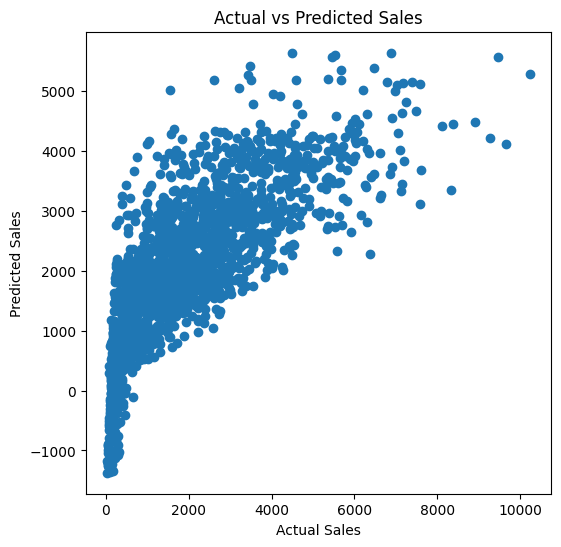

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [20]:
model_results = {
    "Model":["Linear Regression","Random Forest"],
    "RMSE":[rmse, rmse_rf],
    "R2 Score":[r2,r2_rf]
}

import pandas as pd
results_df = pd.DataFrame(model_results)

results_df

,Model,RMSE,R2 Score
0,Linear Regression,1068.470362,0.579970
1,Random Forest,1092.296902,0.561028


In [21]:
df.to_csv("../dashboard/retail_sales_dashboard_data.csv", index=False)

print("Dashboard dataset exported")

Dashboard dataset exported
